# Oppgave 5.1: Varer på salg

Vi ønsker å undersøke hvordan det å sette varer på tilbud påvirker salg og omsetning

* Anta at en butikk ar et knippe produkter til en viss pris
* Når en kunde kommer inn i butikken er det en viss sjanse knyttet til hvert produkt for at kunden kjøper det
* Dersom varene kommer på salg øker denne sjansen

* Gjør noen antagelser om hvor mange kunder som kommer innom butikken hver dag
* Når en kunde kommer inn i butikken har de et visst budjsett som vi trekker tilfeldig fra en passende fordeling
  - Her kan dere bruke feks `random.gauss()`,`numpy.random.normal()`, `random.uniform()`
* Kunden ser så gjennom produktene og kjøper de basert på tilfeldighet (produktets parametre) og om de har penger igjen i budsjettet

* Sammenlign salg og omsetning for en måned med og uten produkter på tilbud
* Du velger selv hvordan sjansen for salg skal øke med tilbudsrate -- men den logistiske modellen er en god kandidat
* Fremstill resultatet av simulering grafisk med `matplotlib`

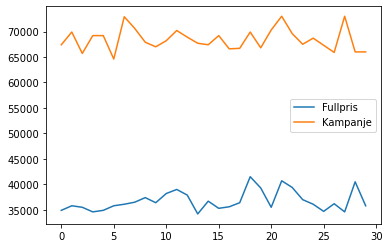

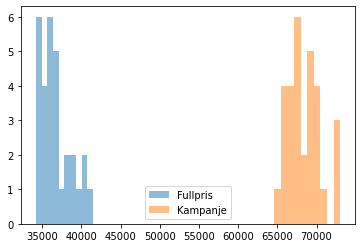

Under kampanjen øker omsetningen med 86%


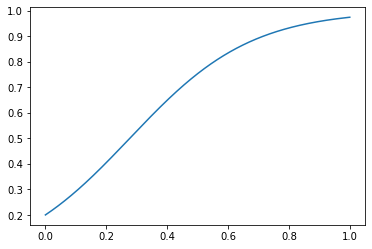

In [53]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
import pprint

pp = pprint.PrettyPrinter(indent=4)


def Ps(disc,P0=0.2,r=5):
    """
    Logistisk modell for salgssannsynlighet gitt %vis avlsag
    """
    K = 1
    A = (K-P0)/P0
    return K/(1+A*np.exp(-(r*disc)))


varer = {"Vare_A": {"pris": 100, "DG": 0.4, "sannsynlighet": 0.2}, 
         "Vare_B": {"pris": 200, "DG": 0.4, "sannsynlighet": 0.2},
         "Vare_C": {"pris": 300, "DG": 0.4, "sannsynlighet": 0.2}
        }

varersalg = {key: val.copy() for key, val in varer.items()} # Deepcopy av varer


middelverdi_budjsett = sum([data["pris"] for _,data in list(varer.items())])/3
standardavvik = 0.2*middelverdi_budjsett

def handle(varer, budsjett):
    """ Funksjon som simulerer en handlene kunde
    Kunden ser på varene i varer [("Vare_A", {"pris": ...}), ("Vare_B", data), ...]
    Kunden har et visst budsjett
    Kunden ser igjennom varene og kjøper de med sannsynlighet data["sannsynlighet"], gitt at det er innenfor budsjett

    Vi returnerer varene som ble kjøpt, totalprisen og det som er igjen på budsjett
    """
    rest = budsjett
    kjop = []
    totpris = 0.0
    for vare, data in varer:
        if random.random() < data["sannsynlighet"] and data["pris"] <= rest:
            rest -= data["pris"]
            totpris += data["pris"]
            kjop.append(vare)
    #pp.pprint(kjop)
    #pp.pprint(totpris)
    return kjop, totpris, rest

def lag_kunde(varedata):
    """ Funksjon som "lager" en kunde
    Vi trekker et budsjett fra en normalfordeling
    Vi må også "shuffle" varene slik at kundene ikke ser på de i samme rekkefølge
    hele tiden

    funksjonen returnerer varene som liste av [("Vare_A", {"pris": ...,...}), ("Vare_B": data), ...]
    og budsjettet til kunden
    """
    budsjett = random.gauss(mu=middelverdi_budjsett, sigma=standardavvik)
    kundevarer = list(varedata.items())
    random.shuffle(kundevarer)
    return budsjett, kundevarer
    
def simuler_dag(n, vareutvalg):
    kjop = []
    forbruk = []
    
    for _ in range(n):
        budsjett, kundevarer = lag_kunde(vareutvalg)
        varekjop, totpris, _ = handle(kundevarer, budsjett)
        kjop.append(varekjop)
        forbruk.append(totpris)
    return forbruk, kjop


def lag_salg(discount= 0.2):
    for vare, data in varersalg.items():
        data["rabatt"] = discount
        data["sannsynlighet"] = Ps(discount, P0=data["sannsynlighet"])
    

daglig_salg = []
daglig_salg_rabatt = []
lag_salg(discount=0.2)

salg_kunde = []
salg_kunde_rabatt = []

for i in range(30):
    salg, _ = simuler_dag(1000,varer)
    daglig_salg.append(sum(salg))
    salg_rabatt, _ = simuler_dag(1000, varersalg)
    daglig_salg_rabatt.append(sum(salg_rabatt))


plt.plot(list(range(30)), daglig_salg, label="Fullpris")
plt.plot(list(range(30)), daglig_salg_rabatt, label="Kampanje")
plt.legend()
plt.show()
plt.hist(daglig_salg, alpha=0.5, label="Fullpris")
plt.hist(daglig_salg_rabatt, alpha=0.5, label="Kampanje")
plt.legend()
plt.show()
print(f"Under kampanjen øker omsetningen med {sum(daglig_salg_rabatt)/sum(daglig_salg)-1:.0%}")

    
rabs = np.linspace(0,1,1000)
prob = Ps(rabs)
plt.plot(rabs, prob)
plt.show()

    
    
            
            
        

# Oppgave 5.2: Simulere markedsdynamikk
1. Set opp en markedsmodell for et gode:
 
* Tilbud: $Q_s = a - bP+\epsilon_s$
* Etterspørsel $Q_d = c + dP +\epsilon_d$
Her er:
* $Q_d =$ Kvantum etterspurt
* $Q_s =$ Kvantum "tilbudt"
* $P = $ Pris
* $a,b,c,d =$ Konstanter dere bestemmer
* $\epsilon_d, \epsilon_s = $ "Sjokk" i markedet for tilbud og etterspørsel

Velg fornuftige verdier for $a,b,c$ og $d$

2. Implementer tilfeldig sjokk i markedet
   * Velg $\epsilon_d$ og $\epsilon_s$ tilfeldig fra en normalfordeling med middelverdi 0 og et passende standardavvik
   * Her kan du bruke `random.gauss(..)` eller numpy sin `np.random.normal(...)`

3. Simuler markedet over tid
   * Simuler et visst antall perioder (feks 50)
   * For hver periode skal du:
     - Regne ut nye markedssjokk $\epsilon_d$ og $\epsilon_s$
     - Bestemme likevektsprisen $P^*$
     - Bestemme likevektskvantumet $Q^*$
4. På et gitt tidspunkt simulerer vi **en** intervensjon (?) i markedet (Feks halveis i simuleringen):
   * Skatt: Øk etterspørselfunksjonens $a$ for å simulere økt beskatning på produksjon
   * Subsidier: Minsk etterspørselfunksjonens $a$ for å simulere subsidier til produksjon
   * Innfør en makspris eller minimumspris
   * Fortsett simuleringen med oppdatert modell for markedsdynamikken

5. Plot resultat med matplotlib
   * Plot likevektspris og likevektskvantum over tid
